In [2]:
from __future__ import annotations
import operator

from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field 
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [15]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(...,description= "what to cover")

In [16]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [17]:
class State(TypedDict):
    topic: str
    plan: Plan

    #reducer : results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [18]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

In [19]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content = (
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content = f"Topic: {state['topic']}")
        ]
    )

    return {"plan": plan}

In [27]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]}) for task in state["plan"].tasks]

In [ ]:
def worker(payload: dict) -> dict:

    #payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"] 

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content = "Write one clean Markdown section."),
            HumanMessage(
                content = (
                    f"Bloag: {blog_title}\n"
                    f"Topic: {topic}\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections":[section_md]}

In [55]:
import re

def safe_filename(title: str) -> str:
    # remove/replace characters invalid in Windows filenames: \ / : * ? " < > |
    name = re.sub(r'[\\/:*?"<>|]', '', title)
    name = re.sub(r'\s+', '_', name.strip())
    return name.lower() + ".md"

In [ ]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [56]:
def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    final_md = f"# {title}\n\n{body}\n"

    filename = safe_filename(title)
    output_path = Path(filename)

    print("CWD:", Path.cwd())
    print("Writing to:", output_path.resolve())
    try:
        output_path.write_text(final_md, encoding="utf-8")
        print("Write succeeded. Exists:", output_path.exists())
    except Exception as e:
        print("WRITE FAILED:", repr(e))

    return {"final": final_md}

In [57]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

In [58]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer",END)

app = g.compile()

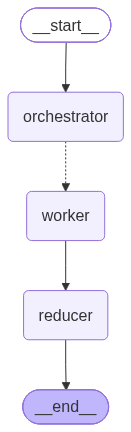

In [59]:
app

In [60]:
out = app.invoke({"topic": "Write a blog on self attention", "sections": []})

CWD: d:\LangGraph\AI_agent_plans
Writing to: D:\LangGraph\AI_agent_plans\understanding_self-attention_the_backbone_of_modern_neural_networks.md
Write succeeded. Exists: True


In [42]:
print(out)

{'topic': 'Write a blog on self attention', 'plan': Plan(blog_title='Understanding Self-Attention: The Backbone of Modern AI Models', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain the concept of self-attention and its importance in machine learning, especially in natural language processing.'), Task(id=2, title='How Self-Attention Works', brief='Describe the mechanics of self-attention, including queries, keys, values, and the attention score calculation.'), Task(id=3, title='Self-Attention vs Traditional Attention Mechanisms', brief='Compare self-attention with other attention mechanisms to highlight its unique benefits.'), Task(id=4, title='Applications of Self-Attention', brief='Discuss the various AI models and domains where self-attention is utilized, such as transformers, BERT, and GPT.'), Task(id=5, title='Advantages and Challenges', brief='Outline the strengths and limitations of self-attention, including computational costs and scalability.'), Task(i